# Autoestudio 6 - Grafos
Al finalizar este autoestudio, habrás adquirido conocimientos para:


1. Explicar las representaciones clásicas de grafos
2. Implementar desde cero grafos usando matrices de adyacencia
3. Comprender los algoritmos de búsqueda por niveles y por profundidad
4. Usar los algoritmos básicos de búsqueda para solucionar problemas


In [ ]:
# @title Ingrese datos
nombre= " " # @param {"type":"string"}
carnet = 1000 # @param {"type":"integer"}


----

# Introduccion

Un grafo es una estructura de datos que representa nodos/vertices $V$ y conexiones (aristas) entre estos $E$. Un grafo sería la combinación de ambos como $G = (V, E)$.

Visto matemáticamente, las conexiones que representamos en el conjunto $E$ estarían dadas como $(u, v) \in E$, donde $u, v \in V$, lo que significa que existe una conexion directa desde $u$ a $v$.

Notese que esta conexion esta dada en un solo sentido, es decir que $u$ esta conectado hacia $v$, pero no necesariamente que $v$ esta conectado hacia $u$.

Considere el siguiente grafo:

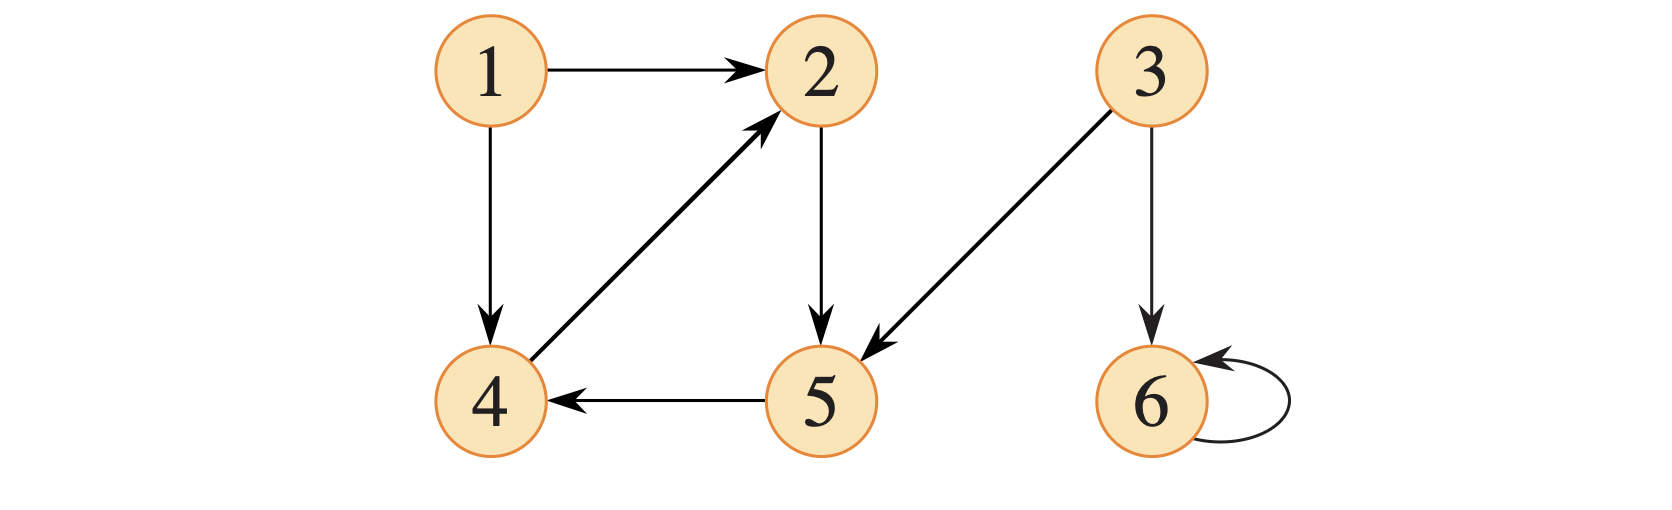

El conjunto $V$ es $\{ 1, 2, 3, 4, 5, 6 \}$. El tamaño del conjunto es $\lvert V \rvert = 6$.

Y tendremos que $E$ es $\{ (1, 2), (1, 4), (2, 5), (3, 5), (3, 6), (4, 2), (5, 4), (6, 6) \}$. El tamaño del conjunto es $\lvert E \rvert = 8 $.

## Representaciones de grafos

A pesar que tenemos un modelo sencillo de interpretar un grafo con ambos conjuntos $V$ y $E$, es necesario ver que podemos representar un grafo de maneras distintas.

Dos de las representaciones más comunes de grafos encontradas en la literatura son: una lista de adyacencia y  una matriz de adyacencia.

**Nota** Por simplicidad asumiremos inicialmente que los vertices contenidos en $V$ son los numeros $\{ 1, 2, \ldots, \lvert V \rvert \}$.

### Lista de adyacencia

El grafo se representa por medio de una lista de listas. Como bien sabemos, las listas son indexadas (cada elemento se accede con un numero de posición), por tanto cada vertice se accedera por este medio.

La lista debera contener $\lvert V \rvert$ listas, llamemosla `adj`, la lista en `adj[u]` contendra la lista de los elementos a los que $u$ esta conectado.

Es decir, si tenemos las aristas $(u, v_1), (u, v_2), \ldots, (u, v_k)$, en la lista `adj[u]` tendremos $[v_1, v_2, \ldots, v_k]$.

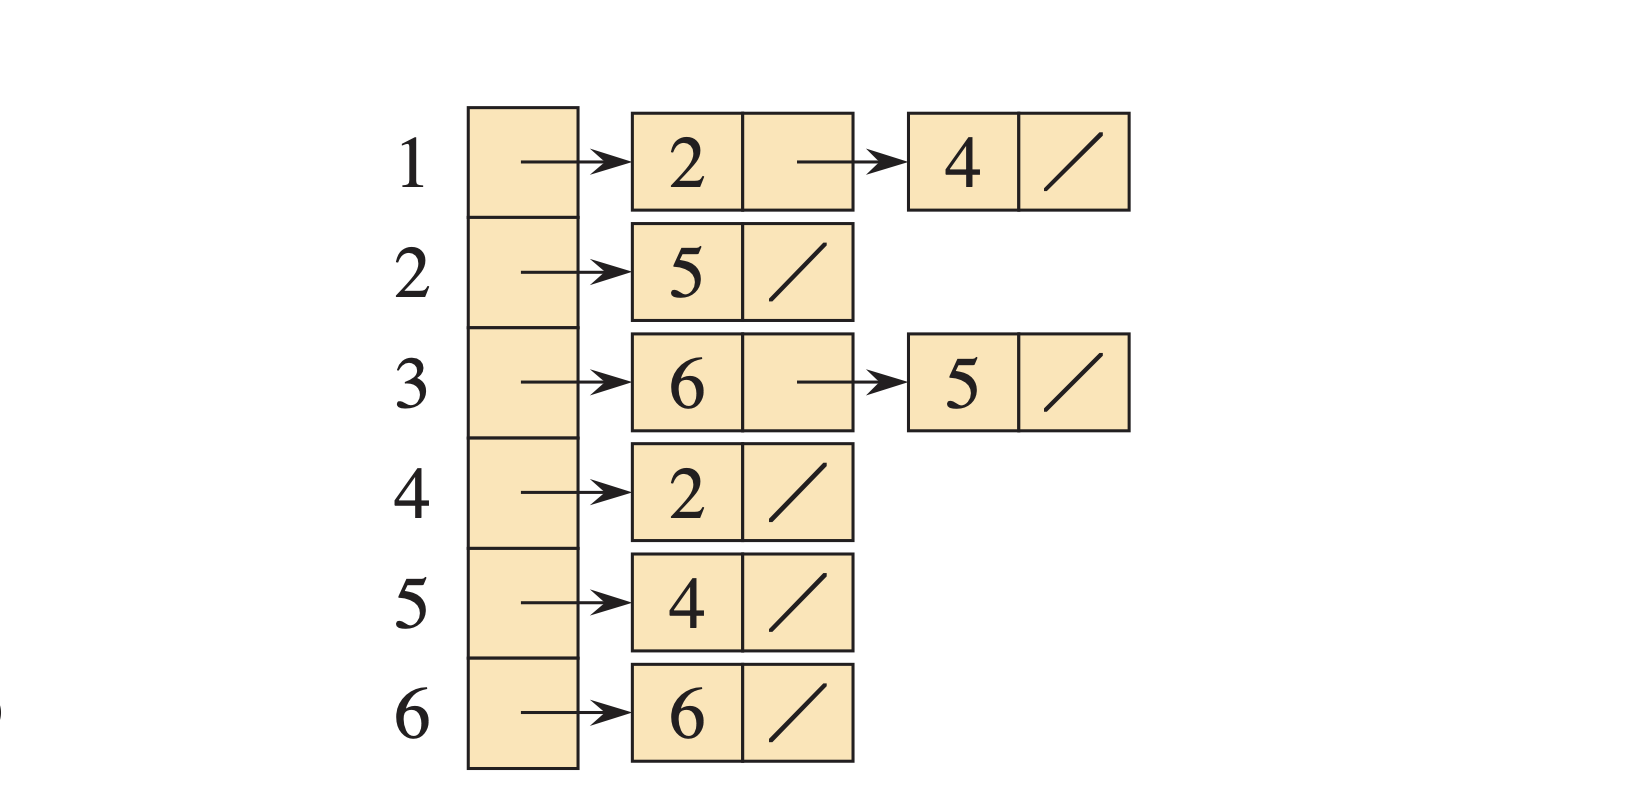

### Matriz de adyacencia

Esta representacion consiste de una matriz $A$ de tamaño $\lvert V \rvert \times \lvert V \rvert$, de manera que la posicion de la matriz en $(u, v)$ es:
$$
A[u][v] = \begin{cases}
  1 & \text{si } (u, v) \in E \\
  0 & \text{sino}
\end{cases}
$$

Usando el mismo grafo del ejemplo anterior tenemos:

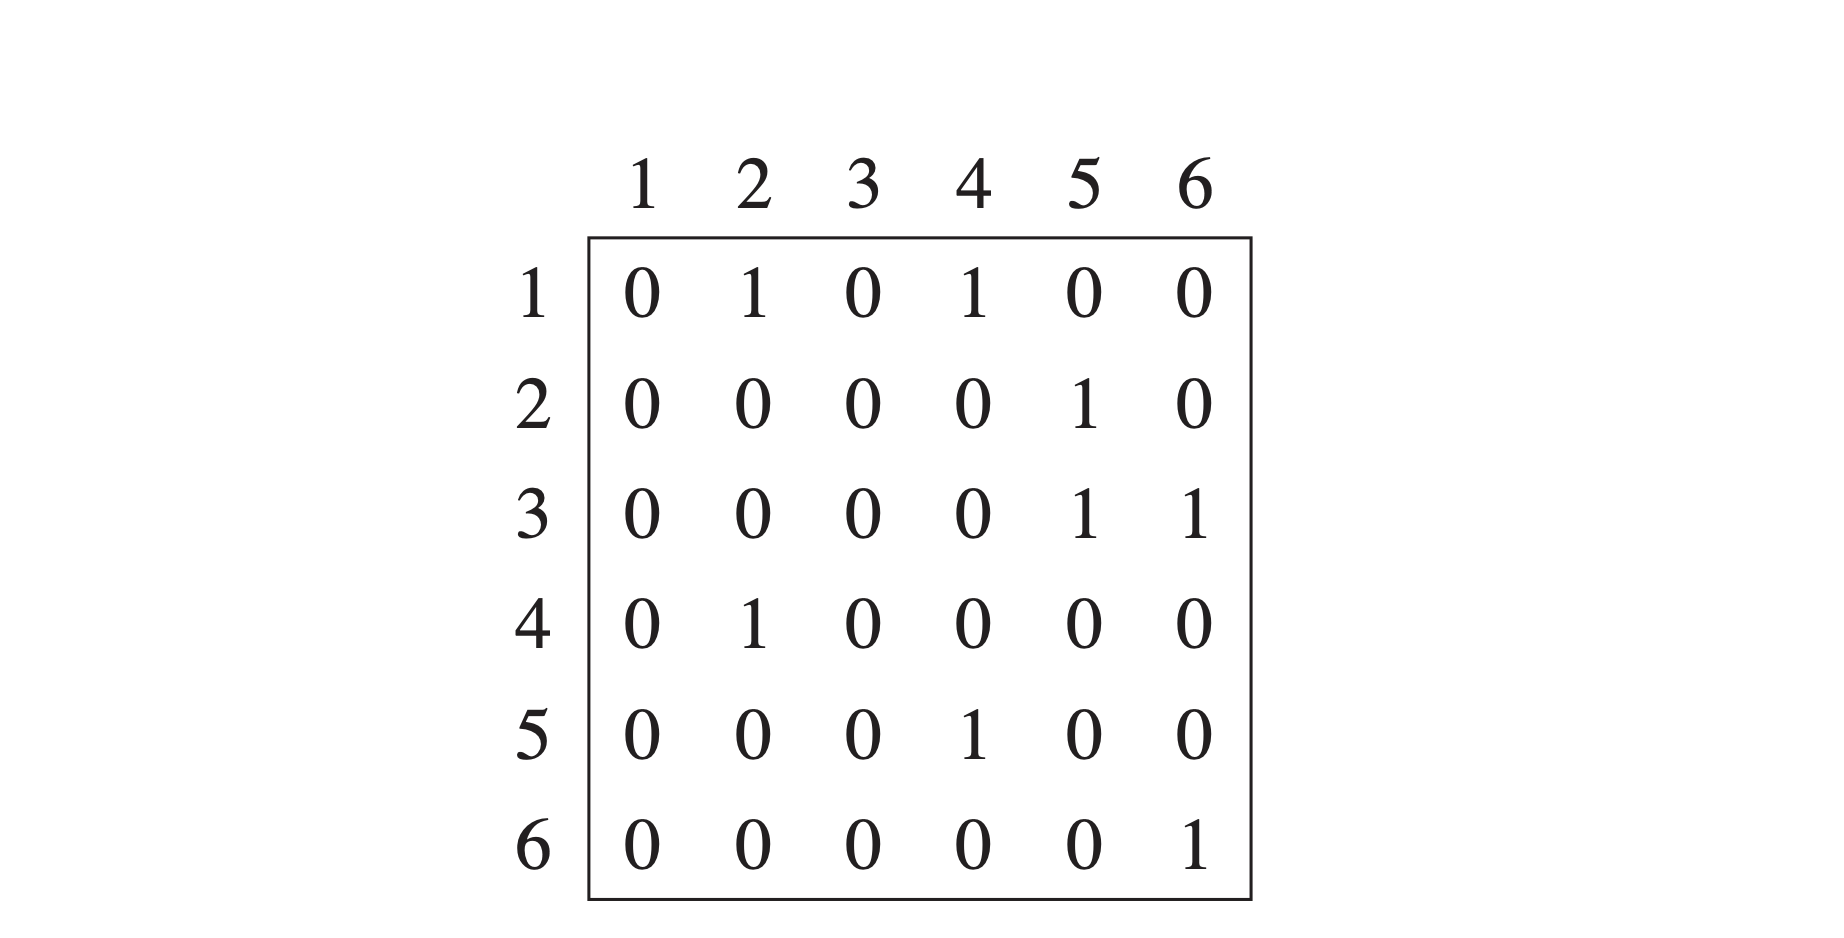

Donde las filas representan a los nodos de origen que denominaremos siempre como $u$, y las columnas los nodos destino, que denominaremos como $v$.

## Tipo `Graph`

Con esto en mente podemos crear nuestra estructura de datos que nos permitira manipular nuestro grafo. Particularmente queremos poder modificar nuestro grafo internamente para agregar conexiones, o consultar a que esta conectado cada uno de nuestros vertices.

Por ahora definamos que nuestro tipo grafo tenga tres (3) metodos:
 - `add_edge(u, v)` para agregar la conexion entre $u$ a $v$.
 - `vertices()` para obtener todos los vertices que hace parte de nuestro grafo.
 - `edges(u)` para obtener todos los vertices a los que $u$ se conecta.

### Lista de adyacencia

Ahora implementemos nuestra clase `Graph` por medio de usar una lista de adyacencia.

Tomemos que $n = \lvert V \rvert$, por lo que lo recibiremos como parametro para inicializar nuestro grafo.

In [ ]:
class Graph:
  def __init__(self, n: int):
    assert n > 0
    self.adj = [[] for _ in range(n)]

  def add_edge(self, u: int, v: int):
    pass
  def edges(self, u: int) -> list[int]:
    pass
  def vertices(self) -> list[int]:
    pass


Ahora definamos el metodo `add_edge` y el metodo `edges`.

In [ ]:
def add_edge(g: Graph, u: int, v: int):
  n = len(g.adj)
  assert 0 <= u < n
  assert 0 <= v < n
  g.adj[u].append(v)

def edges(g: Graph, u: int) -> list[int]:
  n = len(g.adj)
  assert 0 <= u < n
  return g.adj[u].copy()

def vertices(g: Graph) -> list[int]:
  n = len(g.adj)
  return [i for i in range(n)]

In [ ]:
# Ahora agregemos estas funciones como metodos de nuestra clase `Graph`

Graph.add_edge = add_edge
Graph.edges = edges
Graph.vertices = vertices

Podemos realizar unas pruebas sencillas para verificar que nuestro grafo funciona correctamente.

In [ ]:
def test_graph():
  g = Graph(5)
  edges = [
      (0, 1),
      (1, 2),
      (2, 3),
      (4, 1),
  ]

  for u, v in edges:
    g.add_edge(u, v)

  for u, v in edges:
    assert v in g.edges(u), f"el nodo {v} debe estar dentro de las aristas de {u}"

  vertices = g.vertices()
  assert all(i in vertices for i in range(5)), "todos los vertices desde 0 hasta 4 deben estar"

test_graph()

### Grafiquemos

Ahora para lograr graficar un grafo en este cuaderno usaremos la funcion `draw` que recibira como parametro un grafo `Graph`. Como segundo parametro indicaremos si el grafo es dirigido o no dirigido (por omisión asumiremos que es dirigido).

In [ ]:
def draw(graph: Graph, directed: bool = True):
  pass

Por ahora no nos interesa entender los detalles de como este grafo puede ser dibujado en pantalla dentro de Google Colab, lo dejaremos como un 🪄 _misterio_ 🎩 de la siguiente casilla. _Si desea conocer los detalles basta con expandir la casilla._

In [ ]:
# @title Ejecute esta celda para definir el metodo `draw`

import graphviz as gv
from typing import Any

def draw(g: Graph | None, directed: bool = True):
  if directed:
    dot = gv.Digraph()
  else:
    dot = gv.Graph()

  dot.strict = True
  dot.attr(bgcolor='lightgray')

  default_metadata = {
    "fillcolor": 'white',
    "fontcolor": 'black',
    "style": "filled",
    "shape": "circle",
  }

  for u in g.vertices():
    meta = default_metadata
    dot.node(str(id(u)),
            label=str(u),
            **meta)

  for u in g.vertices():
    for v in g.edges(u):
      dot.edge(str(id(u)), str(id(v)))

  return dot

In [ ]:
# Definamos nuestro grafo

g = Graph(5)
g.add_edge(0, 1)
g.add_edge(0, 3)
g.add_edge(3, 1)
g.add_edge(1, 4)
g.add_edge(4, 3)
g.add_edge(2, 1)

draw(g)

### $\color{blue}{Ejercicios}$

1. **Implemente** la clase `GraphAM` para utilizar la representacion con matriz de adyacencia. Muestre un ejemplo sencillo con el que funciona y grafiquelo.

In [ ]:
class GraphAM:
  def __init__(self, n: int):
    assert n > 0
    self.A = [[0 for _ in range(n)] for _ in range(n)]

  def add_edge(self, u: int, v: int):
    pass
  def edges(self, u: int) -> list[int]:
    pass
  def vertices(self) -> list[int]:
    pass

Tambien utilice las pruebas del punto anterior para verificar que su solucion es correcta.

In [ ]:
def test_graph():
  g = GraphAM(5)
  edges = [
      (0, 1),
      (1, 2),
      (2, 3),
      (4, 1),
  ]

  for u, v in edges:
    g.add_edge(u, v)

  for u, v in edges:
    assert v in g.edges(u), f"el nodo {v} debe estar dentro de las aristas de {u}"

  vertices = g.vertices()
  assert all(i in vertices for i in range(5)), "todos los vertices desde 0 hasta 4 deben estar"

test_graph()

2. **Investigue** cuando es deseable una representacion de datos versus la otra (listas de adyancecia vs matriz de adyacencia). Argumente con los valores de $\lvert V \rvert$ y $\lvert E \rvert$.

----

# Busqueda por anchura (BFS)

El algoritmo de búsqueda por amplitud consiste en que dado un grafo $G = (V, E)$ y un punto de inicio $s \in V$ se haga una exploración del grafo donde todos los nodos a una distancia $k$ sean visitados antes que cualquier nodo a distancia $k+1$.

Para realizar esta exploracion es necesario estar pendiente de que nodos del grafo hemos visitado anteriormente, esto debido a que pueden existir ciclos.

Nuestro algoritmo de busqueda consiste en dos etapas:
 - Iniciacion
 - Exploracion

Para la parte de _iniciacion_, establecemos el estado inicial para los nodos en nuestra busqueda:
 - Ningun nodo ha sido visitado (en el contexto del libro, serian de color blanco)
 - La distancia inicial de todos los nodos no esta determinada (hacemos alusión a esto usando un valor comodin como $\infty$ o $-1$).
 - Todos los nodos no tienen un predecesor (que estaria denotado como $\pi = \text{NIL}$)

El unico nodo que inicialmente tiene su distancia definida es $s$, con distancia $0$ (distancia consigo mismo).

Para la _exploracion_, queremos procesar los nodos en el orden en la que van llegando (FIFO), por lo que naturalmente utilizamos una cola para procesar nuestros nodos. A medida que vamos procesando cada nodo, vamos agregando tambien los nuevos nodos que vamos encontrando.

Usaremos la clase `deque` de la libreria estandar de Python en `collections` como cola. Documentada [aqui](https://docs.python.org/es/3.12/library/collections.html#collections.deque).

In [ ]:
from collections import deque

def bfs(g: Graph, s: int):
  vertices: list[int] = g.vertices()
  n = len(vertices)

  # Iniciacion
  is_visited = [False for _ in range(n)]
  distances: list[int] = [-1 for _ in range(n)]
  predecessors: list[int | None] = [None for _ in range(n)]

  Q = deque()
  distances[s] = 0
  is_visited[s] = True
  Q.append(s)

  # Exploracion
  while len(Q) != 0:
    u = Q.popleft()
    for v in g.edges(u):
      if not is_visited[v]:
        distances[v] = distances[u] + 1
        predecessors[v] = u
        is_visited[v] = True
        Q.append(v)

  return distances, predecessors, is_visited

Ahora usemos un grafo no dirigido sencillo, y grafiquemos el resultado de la exploracion con este algoritmo.

In [ ]:
g = Graph(6)

edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 0),
    (4, 5),
]

for u, v in edges:
  g.add_edge(u, v)
  g.add_edge(v, u) # Grafo no dirigido, por lo que (u, v) implica tambien (v, u)

distances, predecessors, visited = bfs(g, 0)

Notese que luego de realizar la exploracion, se calculan las distancias que minimas entre el nodo $0$ con todos los demas nodos que estan conectados, y que los nodos que no estan conectados nunca son explorados (se mantienen en blanco).

Si queremos visualizar nuestra exploracion vamos a usar otro metodo llamado `draw_bfs`, que utilizara los datos de nuestro algoritmo para mostrar el estado final.

**Nota** Las flechas de color azul indican los predecesores de cada nodo.

In [ ]:
# @title Ejecute esta celda para definir el metodo `draw_bfs`

import graphviz as gv
from typing import Any

def draw_bfs(g: Graph | None, distances, predecessors, visited, directed: bool = False):
  dot = gv.Digraph()

  dot.strict = False
  dot.attr(bgcolor='lightgray')

  default_metadata = {
    "fillcolor": 'white',
    "fontcolor": 'black',
    "style": "filled",
    "shape": "circle",
  }

  for u in g.vertices():
    meta = dict(default_metadata, **{
        "fontcolor": 'white' if visited[u] else 'black',
        "fillcolor": 'black' if visited[u] else 'white',
        "xlabel": str(distances[u]) if visited[u] else '∞',
    })

    dot.node(str(id(u)),
            label=str(u),
            **meta)

  already_added = set()

  for u in g.vertices():
    for v in g.edges(u):
      if (v, u) not in already_added and (u, v) not in already_added:
        dot.edge(
            str(id(u)),
            str(id(v)),
            dir = 'none' if not directed else 'forward',
        )
        already_added.add((u, v))

  for u, pred in enumerate(predecessors):
    if pred is not None:
      dot.edge(
          str(id(u)),
          str(id(pred)),
          constraint = 'true',
          color = 'blue',
          style = 'dashed',
          dir = 'forward',
          arrowhead = 'normal',
      )

  return dot


In [ ]:
print(distances, predecessors, visited)
draw_bfs(g, distances, predecessors, visited)

In [ ]:
g = Graph(5)
edges = [
    (0, 1),
    (0, 2),
    (1, 2),
    (3, 4),
    (1, 4),
]

for u, v in edges:
  g.add_edge(u, v)
  g.add_edge(v, u)

distances, predecessors, visited = bfs(g, 1)
print(distances, predecessors, visited)
draw_bfs(g, distances, predecessors, visited)

Para este grafo de ejemplo, haciendo la busqueda desde el nodo $s = 1$, si obtenemos el camino minimo desde $s$ hasta $u=3$, entonces el camino para llegar desde $s$ hasta $u$ seria $1 \rightarrow 4\rightarrow 3$.

### $\color{blue}{Ejercicios}$

1. **Implemente** la funcion `calculate_distance`, que tome como entrada un grafo, un punto de inicio $s$ y un nodo $u$ del que queremos conocer su distancia. En caso de no ser alcanzable, devuelva $-1$.

In [ ]:
def calculate_distance(g: Graph, s: int, u: int) -> int:
  # Implemente
  return 0

2. **Implemente** la funcion `path`, que dado el arreglo de predecesores de nuestro grafo, calcule el camino minimo desde $s$ hasta un nodo $u$.

In [ ]:
def path(predecessor: list[int | None], u: int) -> list[int]:
  # Implemente
  return []

assert path(predecessors, 3) == [1, 4, 3]

3. **Implemente** la funcion `is_reachable` para que dado un grafo $G$ y un nodo $s$, determine si un nodo $u$ es alcanzable (existe algun camino) desde $s$ hasta $u$.

In [ ]:
def is_reachable(g: Graph, s: int, u: int) -> bool:
  # Implemente
  pass

# Busqueda por profundidad (DFS)

El algoritmo de búsqueda por profundidad, como su nombre sugiere, prioriza realizar la búsqueda primero por cada uno de los nodos que va descubriendo, de manera que llegamos a lo mas profundo que podamos explorar antes de seguir por otras ramas que se encuentren en el grafo.

De manera similar a la búsqueda por anchura, debemos tener presente que nodos hemos visitado cuando hacemos la exploracion. Asi mismo, el algoritmo tambien comprende las mismas dos (2) partes descritas en BFS: Iniciacion y exploracion.

A diferencia de BFS, este algoritmo no consta necesariamente de un nodo fuente $s$, sino que usualmente realizamos una exploracion de todos los nodos dentro de nuestro grafo que no hayamos visitado.

Este algoritmo es recursivo por naturaleza, sin embargo este tambien puede ser implementado de manera iterativa, y para esto vamos a hacer uso de una **pila**.

In [ ]:
from collections import deque

def dfs(g: Graph):
  vertices = g.vertices()
  n = len(vertices)
  is_visited: list[bool] = [False for _ in range(n)]
  distances: list[int] = [-1 for _ in range(n)]
  predecessors: list[int | None] = [None for _ in range(n)]

  S = deque()
  for u in vertices:
    # apilamos todos los vertices para asegurarnos de que todos los vamos a explorar
    S.append(u)

  while len(S) != 0:
    u = S.pop()
    if not is_visited[u]:
      is_visited[u] = True
      distances[u] = 0

    for v in g.edges(u):
      if not is_visited[v]:
        distances[v] = distances[u] + 1
        predecessors[v] = u
        is_visited[v] = True
        S.append(v)

  return distances, predecessors, is_visited

In [ ]:
g = Graph(7)
edges = [
    (6, 5),
    (6, 4),
    (5, 4),
    (5, 4),
    (3, 2),
    (5, 2),
    (1, 0),
]

for u, v in edges:
  g.add_edge(u, v)

draw(g, directed = True)

In [ ]:
distances, predecessors, visited = dfs(g)

In [ ]:
# @title Ejecute esta celda para definir el metodo `draw_dfs`

import graphviz as gv
from typing import Any

def draw_dfs(g: Graph | None, distances, predecessors, visited, directed: bool = True):
  if directed:
    dot = gv.Digraph()
  else:
    dot = gv.Graph()

  dot.strict = True
  dot.attr(bgcolor='lightgray')

  default_metadata = {
    "fillcolor": 'white',
    "fontcolor": 'black',
    "style": "filled",
    "shape": "circle",
  }

  for u in g.vertices():
    meta = dict(default_metadata, **{
        "fontcolor": 'white' if visited[u] else 'black',
        "fillcolor": 'black' if visited[u] else 'white',
        "xlabel": str(distances[u]) if visited[u] else '∞',
    })

    dot.node(str(id(u)),
            label=str(u),
            **meta)

  for u in g.vertices():
    for v in g.edges(u):
      dot.edge(str(id(u)), str(id(v)))

  for u, pred in enumerate(predecessors):
    if pred is not None:
      dot.edge(str(id(u)),
               str(id(pred)),
               constraint = 'false',
               color = 'blue',
               style = 'dashed',
               )

  return dot


In [ ]:
draw_dfs(g, distances, predecessors, visited)

### $\color{blue}{Ejercicios}$

1. **Implemente** la funcion `path`, que dado el arreglo de predecesores de nuestro grafo, calcule el camino minimo desde $s$ hasta un nodo $u$.

In [ ]:
g = Graph(5)
edges = [
    (4, 3),
    (4, 2),
    (3, 2),
    (1, 0),
    (3, 0),
]

for u, v in edges:
  g.add_edge(u, v)

distances, predecessors, visited = dfs(g)
print(distances, predecessors, visited)
draw_dfs(g, distances, predecessors, visited)

Para este grafo de ejemplo, haciendo la busqueda desde el nodo $s = 4$, si obtenemos el camino desde $s$ hasta $u=0$, entonces el camino para llegar desde $s$ hasta $u$ seria $4 \rightarrow 3\rightarrow 0$.

In [ ]:
def path(predecessor: list[int | None], u: int) -> list[int]:
  # Implemente
  return []

assert path(predecessors, 4) == [4, 3, 0]

2. **Implemente** la funcion `is_reachable` para que dado un grafo $G$ y un nodo $s$, determine si un nodo $u$ es alcanzable (existe algun camino) desde $s$ hasta $u$.

In [ ]:
def is_reachable(g: Graph, s: int, u: int) -> bool:
  # Implemente
  pass